# Indian Pines — EDA

In [4]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')

## Завантаження даних

In [5]:
mat = sio.loadmat('../data/IP/Indian_pines_corrected.mat')
X = mat['indian_pines_corrected'].astype(np.float32)  # (145, 145, 200)
y = np.load('../data/IP/IPgt.npy').astype(np.int32)       # (145, 145)

print('Куб даних X:', X.shape, '  dtype:', X.dtype)
print('Ground truth y:', y.shape, '  dtype:', y.dtype)

Куб даних X: (145, 145, 200)   dtype: float32
Ground truth y: (145, 145)   dtype: int32


## Базові параметри

In [6]:
H, W, C = X.shape
n_classes = len(np.unique(y)) - 1  # без фону (0)
total_pixels = H * W
labeled_pixels = np.sum(y > 0)
background_pixels = np.sum(y == 0)

print(f'Розміри сцени:       {H} x {W} пікселів')
print(f'Кількість каналів:   {C}')
print(f'Кількість класів:    {n_classes}')
print(f'Всього пікселів:     {total_pixels}')
print(f'Розмічених (не фон): {labeled_pixels} ({labeled_pixels/total_pixels*100:.1f}%)')
print(f'Фон (клас 0):        {background_pixels} ({background_pixels/total_pixels*100:.1f}%)')

Розміри сцени:       145 x 145 пікселів
Кількість каналів:   200
Кількість класів:    16
Всього пікселів:     21025
Розмічених (не фон): 10249 (48.7%)
Фон (клас 0):        10776 (51.3%)


## Розподіл класів

In [7]:
CLASS_NAMES = {
    1:  'Alfalfa',
    2:  'Corn-notill',
    3:  'Corn-mintill',
    4:  'Corn',
    5:  'Grass-pasture',
    6:  'Grass-trees',
    7:  'Grass-pasture-mowed',
    8:  'Hay-windrowed',
    9:  'Oats',
    10: 'Soybean-notill',
    11: 'Soybean-mintill',
    12: 'Soybean-clean',
    13: 'Wheat',
    14: 'Woods',
    15: 'Buildings-Grass-Trees-Drives',
    16: 'Stone-Steel-Towers',
}

counts = {cls: int(np.sum(y == cls)) for cls in range(1, 17)}
print('-' * 62)
for cls, cnt in counts.items():
    print(f'{cls:>4}  {CLASS_NAMES[cls]:<35} {cnt:>10}  {cnt/labeled_pixels*100:>6.2f}%')

values = list(counts.values())
mode_cls = max(counts, key=counts.get)
min_cls  = min(counts, key=counts.get)
print(f'\nМода (найбільший клас): {mode_cls} — {CLASS_NAMES[mode_cls]} ({counts[mode_cls]} px)')
print(f'Мінімальний клас:       {min_cls} — {CLASS_NAMES[min_cls]} ({counts[min_cls]} px)')
print(f'Середнє по класах:      {np.mean(values):.1f} px')
print(f'Медіана по класах:      {np.median(values):.1f} px')

--------------------------------------------------------------
   1  Alfalfa                                     46    0.45%
   2  Corn-notill                               1428   13.93%
   3  Corn-mintill                               830    8.10%
   4  Corn                                       237    2.31%
   5  Grass-pasture                              483    4.71%
   6  Grass-trees                                730    7.12%
   7  Grass-pasture-mowed                         28    0.27%
   8  Hay-windrowed                              478    4.66%
   9  Oats                                        20    0.20%
  10  Soybean-notill                             972    9.48%
  11  Soybean-mintill                           2455   23.95%
  12  Soybean-clean                              593    5.79%
  13  Wheat                                      205    2.00%
  14  Woods                                     1265   12.34%
  15  Buildings-Grass-Trees-Drives               386    3.77%
  16  S

/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_25496/603083430.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CLASS_NAMES[c] for c in counts], rotation=45, ha='right', fontsize=8)


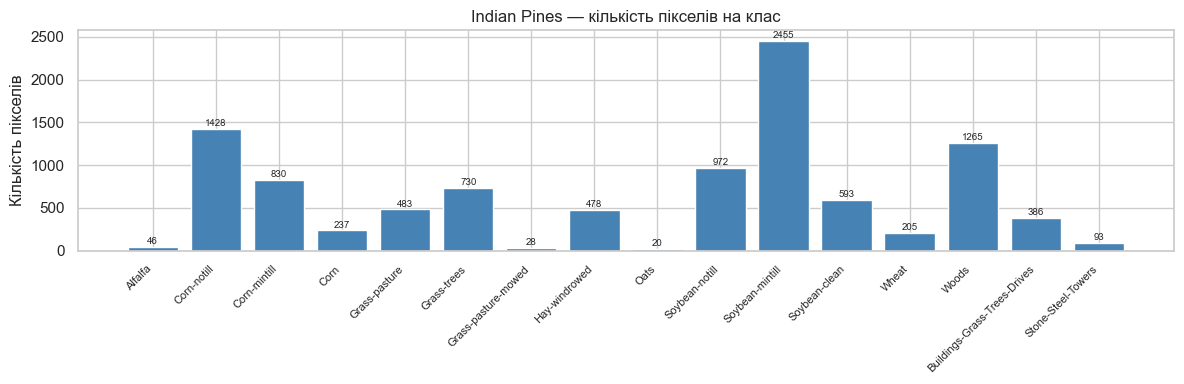

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar([CLASS_NAMES[c] for c in counts], counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Indian Pines — кількість пікселів на клас')
ax.set_ylabel('Кількість пікселів')
ax.set_xticklabels([CLASS_NAMES[c] for c in counts], rotation=45, ha='right', fontsize=8)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(v), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Спектральні характеристики

Глобальні статистики по спектральних каналах:
  Min:  955.0000
  Max:  9604.0000
  Mean: 2652.3889
  Std:  1592.3401


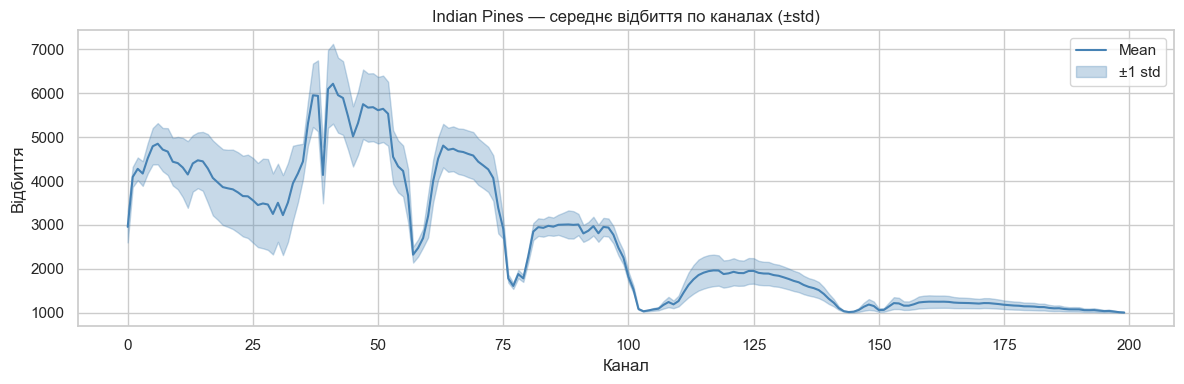

In [9]:
X_flat = X.reshape(-1, C)  # (21025, 200)
print('Глобальні статистики по спектральних каналах:')
print(f'  Min:  {X_flat.min():.4f}')
print(f'  Max:  {X_flat.max():.4f}')
print(f'  Mean: {X_flat.mean():.4f}')
print(f'  Std:  {X_flat.std():.4f}')

channel_means = X_flat.mean(axis=0)
channel_stds  = X_flat.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(channel_means, label='Mean', color='steelblue')
ax.fill_between(range(C), channel_means - channel_stds, channel_means + channel_stds,
                alpha=0.3, color='steelblue', label='±1 std')
ax.set_title('Indian Pines — середнє відбиття по каналах (±std)')
ax.set_xlabel('Канал')
ax.set_ylabel('Відбиття')
ax.legend()
plt.tight_layout()
plt.show()

## Ground truth map

/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_25496/1499049458.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 17)


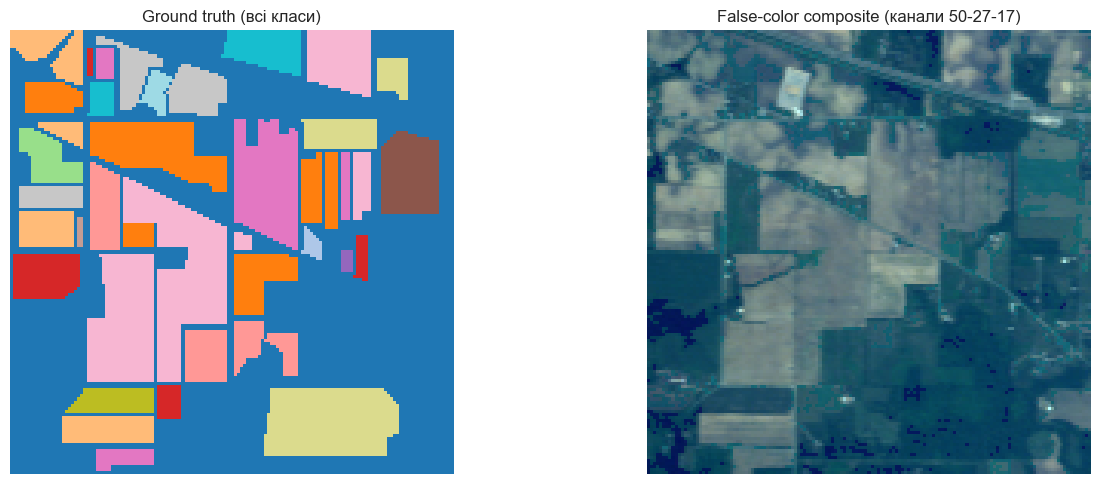

In [10]:
cmap = plt.cm.get_cmap('tab20', 17)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(y, cmap=cmap, vmin=0, vmax=16)
axes[0].set_title('Ground truth (всі класи)')
axes[0].axis('off')

# RGB composit з каналів 50, 27, 17 (приблизно R,G,B для AVIRIS)
rgb = X[:, :, [26, 15, 5]]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
axes[1].imshow(rgb)
axes[1].set_title('False-color composite (канали 50-27-17)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Аутлаєри в межах одного класу (сирий спектр vs PCA)

Питання: чи варто шукати викиди на **сирих** відбиттях (200 каналів) чи в просторі **PCA** (як у `baseline/improved` — 150 компонент)?

- **Сирий спектр** — фізична інтерпретація (шум, змішані пікселі, можливі помилки розмітки), але відстань у 200D нестабільна.
- **PCA** — те, що реально бачить модель і на чому працює FPS + фільтр `outlier_std=2.5` у `improved/dataset.py`.

Нижче — один клас, порівняння обох просторів і той самий критерій, що в тренувальному спліті.


Клас 11: Soybean-mintill  |  пікселів: 2455
Критерій: відстань до центроїда класу > mean + 2.5·std

Простір                           Викидів       %       поріг
--------------------------------------------------------------
Сирий спектр (200 кан.)               107    4.4%    7822.574
Z-score по каналах (200 кан.)         110    4.5%      15.886
PCA (150 компонент)                   110    4.5%      15.884


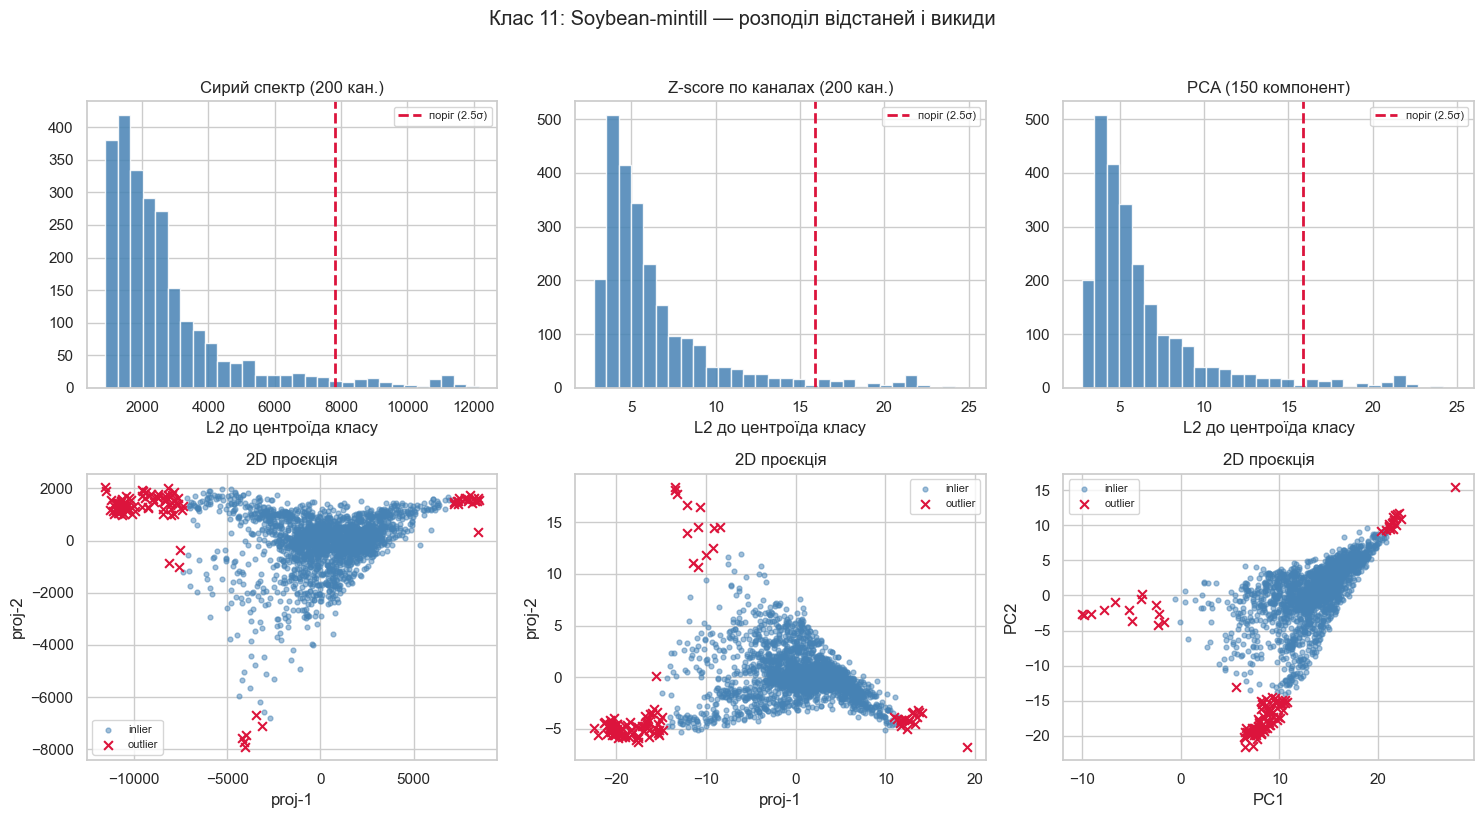

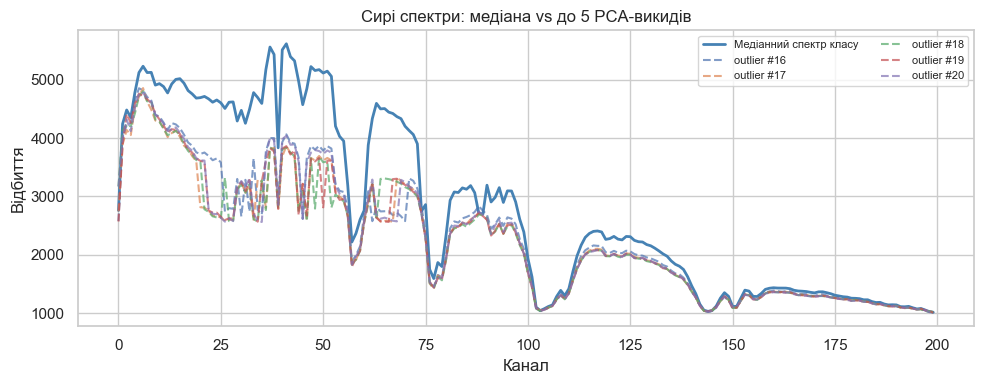

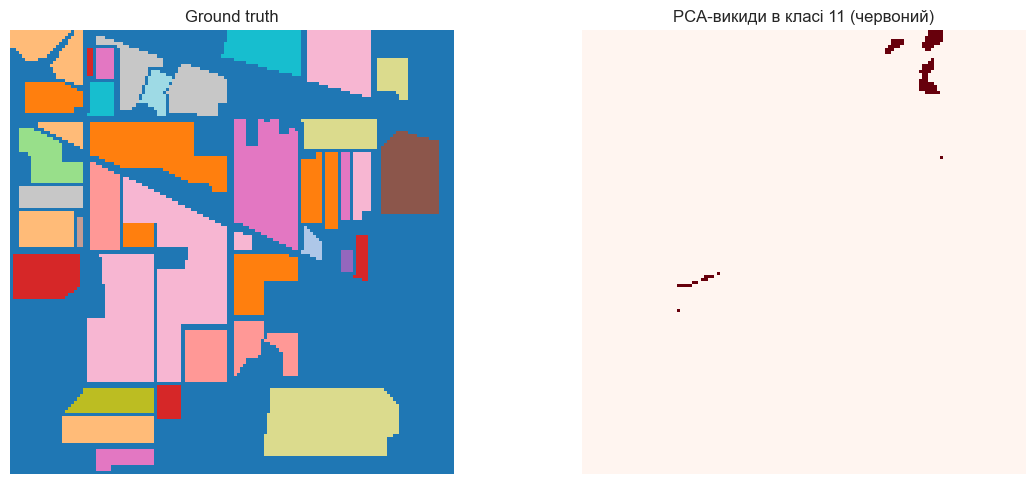


--- Висновок ---
Картини близькі — викиди стабільні; для рішень у пайплайні все одно краще PCA.

Практична порада: EDA на сирому спектрі — щоб зрозуміти «що не так»; рішення про train/val (FPS, outlier_std=2.5) — у просторі PCA, бо модель навчається саме на ньому.


In [11]:
from sklearn.decomposition import PCA

TARGET_CLASS = 11          # змініть на інший клас (1–16)
OUTLIER_STD = 2.5          # як у improved/dataset.py (_fps_indices)
N_PCA = 150                # як у baseline/improved config для IP

mask = y == TARGET_CLASS
pos = np.argwhere(mask)
specs_raw = X[pos[:, 0], pos[:, 1]]
n_px = len(specs_raw)

flat = X.reshape(-1, C)
flat_z = (flat - flat.mean(0)) / (flat.std(0) + 1e-8)
pca = PCA(n_components=N_PCA, svd_solver='randomized', random_state=42)
X_pca = pca.fit_transform(flat_z).reshape(H, W, N_PCA)
specs_pca = X_pca[pos[:, 0], pos[:, 1]]
specs_z = flat_z.reshape(H, W, C)[pos[:, 0], pos[:, 1]]


def outlier_report(vectors, label, outlier_std=OUTLIER_STD):
    centroid = vectors.mean(axis=0)
    d = np.linalg.norm(vectors - centroid, axis=1)
    thr = d.mean() + outlier_std * d.std()
    is_out = d > thr
    return dict(
        label=label,
        vectors=vectors,
        dist=d,
        threshold=thr,
        n_out=int(is_out.sum()),
        pct_out=100 * is_out.mean(),
        is_out=is_out,
    )


reports = [
    outlier_report(specs_raw, 'Сирий спектр (200 кан.)'),
    outlier_report(specs_z, 'Z-score по каналах (200 кан.)'),
    outlier_report(specs_pca, f'PCA ({N_PCA} компонент)'),
]

print(f'Клас {TARGET_CLASS}: {CLASS_NAMES[TARGET_CLASS]}  |  пікселів: {n_px}')
print(f'Критерій: відстань до центроїда класу > mean + {OUTLIER_STD}·std\n')
print(f'{"Простір":<32} {"Викидів":>8}  {"%":>6}  {"поріг":>10}')
print('-' * 62)
for r in reports:
    print(f'{r["label"]:<32} {r["n_out"]:>8}  {r["pct_out"]:>5.1f}%  {r["threshold"]:>10.3f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, r in enumerate(reports):
    d, is_out = r['dist'], r['is_out']
    axes[0, col].hist(d, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, col].axvline(r['threshold'], color='crimson', ls='--', lw=2,
                         label=f'поріг ({OUTLIER_STD}σ)')
    axes[0, col].set_title(r['label'])
    axes[0, col].set_xlabel('L2 до центроїда класу')
    axes[0, col].legend(fontsize=8)

    if col == 2:
        pts = specs_pca[:, :2]
        xlab, ylab = 'PC1', 'PC2'
    else:
        pca2 = PCA(n_components=2, random_state=42)
        pts = pca2.fit_transform(r['vectors'])
        xlab, ylab = 'proj-1', 'proj-2'
    inlier = ~is_out
    axes[1, col].scatter(pts[inlier, 0], pts[inlier, 1], s=12, alpha=0.5, c='steelblue', label='inlier')
    axes[1, col].scatter(pts[is_out, 0], pts[is_out, 1], s=40, c='crimson', marker='x', label='outlier')
    axes[1, col].set_xlabel(xlab)
    axes[1, col].set_ylabel(ylab)
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_title('2D проєкція')

plt.suptitle(f'Клас {TARGET_CLASS}: {CLASS_NAMES[TARGET_CLASS]} — розподіл відстаней і викиди', y=1.02)
plt.tight_layout()
plt.show()

r_pca = reports[2]
out_idx = np.where(r_pca['is_out'])[0]
if len(out_idx) == 0:
    print('\nЗа критерієм PCA явних викидів немає.')
else:
    median_spec = np.median(specs_raw, axis=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(median_spec, color='steelblue', lw=2, label='Медіанний спектр класу')
    for i in out_idx[:5]:
        ax.plot(specs_raw[i], alpha=0.7, ls='--', label=f'outlier #{i}')
    ax.set_title('Сирі спектри: медіана vs до 5 PCA-викидів')
    ax.set_xlabel('Канал')
    ax.set_ylabel('Відбиття')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

out_map = np.zeros((H, W), dtype=bool)
out_map[pos[:, 0], pos[:, 1]] = r_pca['is_out']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(y, cmap=cmap, vmin=0, vmax=16)
axes[0].set_title('Ground truth')
axes[1].imshow(out_map, cmap='Reds')
axes[1].set_title(f'PCA-викиди в класі {TARGET_CLASS} (червоний)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

raw_pct, pca_pct = reports[0]['pct_out'], reports[2]['pct_out']
print('\n--- Висновок ---')
if pca_pct < 3 and raw_pct < 3:
    print('Явних викидів мало в обох просторах — агресивне чистіння навряд чи змінить спліт.')
elif abs(raw_pct - pca_pct) > 5:
    print('Частка викидів суттєво різниться між сирим і PCA — для спліту/FPS орієнтуйтесь на PCA.')
else:
    print('Картини близькі — викиди стабільні; для рішень у пайплайні все одно краще PCA.')

print(
    '\nПрактична порада: EDA на сирому спектрі — щоб зрозуміти «що не так»; '
    f'рішення про train/val (FPS, outlier_std={OUTLIER_STD}) — у просторі PCA, '
    'бо модель навчається саме на ньому.'
)


## Викиди по всіх класах (PCA)

Кількість пікселів з відстанню до центроїда класу > mean + 2.5·std у просторі PCA (150 компонент), як у тренувальному пайплайні.


In [12]:
from sklearn.decomposition import PCA

OUTLIER_STD = 2.5
N_PCA = 150

flat = X.reshape(-1, C)
flat_z = (flat - flat.mean(0)) / (flat.std(0) + 1e-8)
pca = PCA(n_components=N_PCA, svd_solver='randomized', random_state=42)
X_pca = pca.fit_transform(flat_z).reshape(H, W, N_PCA)

print(f'PCA: {C} -> {N_PCA} каналів, explained variance: {pca.explained_variance_ratio_.sum():.3f}')
print(f'Критерій викиду: L2 до центроїда класу > mean + {OUTLIER_STD}·std\n')
print(f'{"Кл.":>3}  {"Назва":<35} {"Всього":>7}  {"Викидів":>8}  {"%":>6}')
print('-' * 65)

total_out = 0
total_labeled = 0
for cls in range(1, int(y.max()) + 1):
    pos = np.argwhere(y == cls)
    if len(pos) == 0:
        continue
    vecs = X_pca[pos[:, 0], pos[:, 1]]
    centroid = vecs.mean(axis=0)
    d = np.linalg.norm(vecs - centroid, axis=1)
    thr = d.mean() + OUTLIER_STD * d.std()
    n_out = int((d > thr).sum())
    n_all = len(pos)
    total_out += n_out
    total_labeled += n_all
    print(f'{cls:>3}  {CLASS_NAMES[cls]:<35} {n_all:>7}  {n_out:>8}  {100*n_out/n_all:>5.1f}%')

print('-' * 65)
print(f'{"Σ":>3}  {"усі розмічені":<35} {total_labeled:>7}  {total_out:>8}  {100*total_out/total_labeled:>5.1f}%')


PCA: 200 -> 150 каналів, explained variance: 1.000
Критерій викиду: L2 до центроїда класу > mean + 2.5·std

Кл.  Назва                                Всього   Викидів       %
-----------------------------------------------------------------
  1  Alfalfa                                  46         2    4.3%
  2  Corn-notill                            1428        30    2.1%
  3  Corn-mintill                            830        20    2.4%
  4  Corn                                    237         0    0.0%
  5  Grass-pasture                           483        18    3.7%
  6  Grass-trees                             730        21    2.9%
  7  Grass-pasture-mowed                      28         1    3.6%
  8  Hay-windrowed                           478        25    5.2%
  9  Oats                                     20         0    0.0%
 10  Soybean-notill                          972        32    3.3%
 11  Soybean-mintill                        2455       110    4.5%
 12  Soybean-clean    